<a href="https://colab.research.google.com/github/Shrutisru/academic_research/blob/main/week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Extracting ZIP...
Dataset root : /content/uav_project/data/mav0
সব পাথ ঠিক আছে ✅
OpenCV: 5.0.0
Camera matrix K:
 [[458.654   0.    367.215]
 [  0.    457.296 248.375]
 [  0.      0.      1.   ]]
ব্যবহারযোগ্য ফ্রেম: 3638


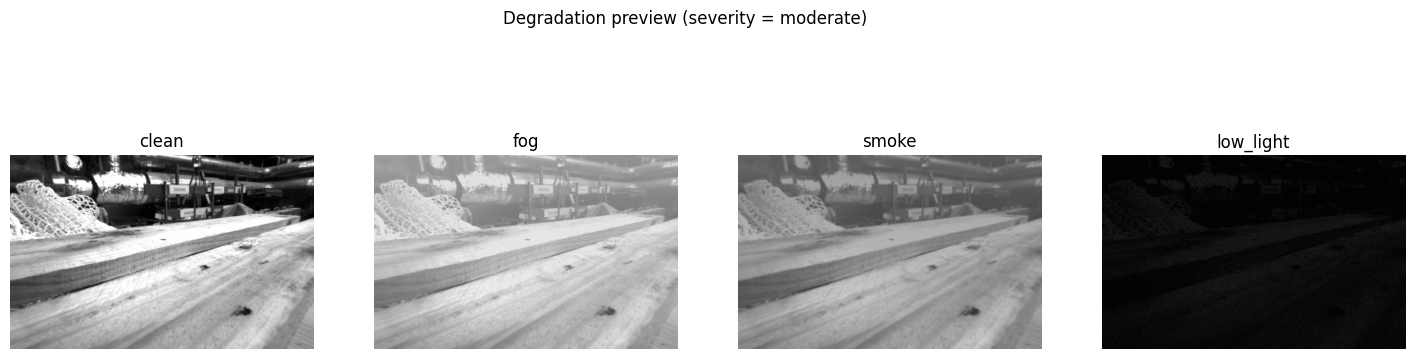


[clean] VO শুরু হচ্ছে... (mode=None, severity=moderate)
  [clean] Frame  1000/3638 | Success:   502 | Failed:   498
  [clean] Frame  1500/3638 | Success:   914 | Failed:   586
  [clean] Frame  2000/3638 | Success:  1319 | Failed:   681
  [clean] Frame  2500/3638 | Success:  1736 | Failed:   764
  [clean] Frame  3500/3638 | Success:  2483 | Failed:  1017
[clean] সম্পন্ন — ATE RMSE: 3.1467 m | RPE RMSE: 0.7779 m | Failed: 28.7%

[fog] VO শুরু হচ্ছে... (mode=fog, severity=moderate)
  [fog] Frame  1500/3638 | Success:   889 | Failed:   611
  [fog] Frame  2000/3638 | Success:  1274 | Failed:   726
  [fog] Frame  2500/3638 | Success:  1670 | Failed:   830
  [fog] Frame  3000/3638 | Success:  2100 | Failed:   900
[fog] সম্পন্ন — ATE RMSE: 3.7962 m | RPE RMSE: 0.7611 m | Failed: 30.1%

[smoke] VO শুরু হচ্ছে... (mode=smoke, severity=moderate)
  [smoke] Frame  1000/3638 | Success:   450 | Failed:   550
  [smoke] Frame  1500/3638 | Success:   830 | Failed:   670
  [smoke] Frame  2000/3638 | Succ

/tmp/ipykernel_6556/4287231436.py:431: RuntimeWarning: invalid value encountered in scalar divide
  scale = (np.sum(D * np.diag(S)) / (np.sum(src_c ** 2) / n)) if with_scale else 1.0


[low_light] সম্পন্ন — ATE RMSE: nan m | RPE RMSE: nan m | Failed: 100.0%

WEEK 3 — CLEAN vs DEGRADED তুলনা
Condition Severity  ATE RMSE (m)  ATE Mean (m)  ATE Max (m)  RPE RMSE (m)  Failed frames (%)  Mean features  Mean inliers  ATE vs clean (x)
    clean        -        3.1467        2.5699       7.3664        0.7779              28.68         2453.1        1522.4              1.00
      fog moderate        3.7962        3.2807       8.2992        0.7611              30.08         1907.2        1187.5              1.21
    smoke moderate        4.1806        3.7314       6.9704        0.6951              34.01         1140.0         714.6              1.33
low_light moderate           NaN           NaN          NaN           NaN             100.00           95.9           7.2               NaN


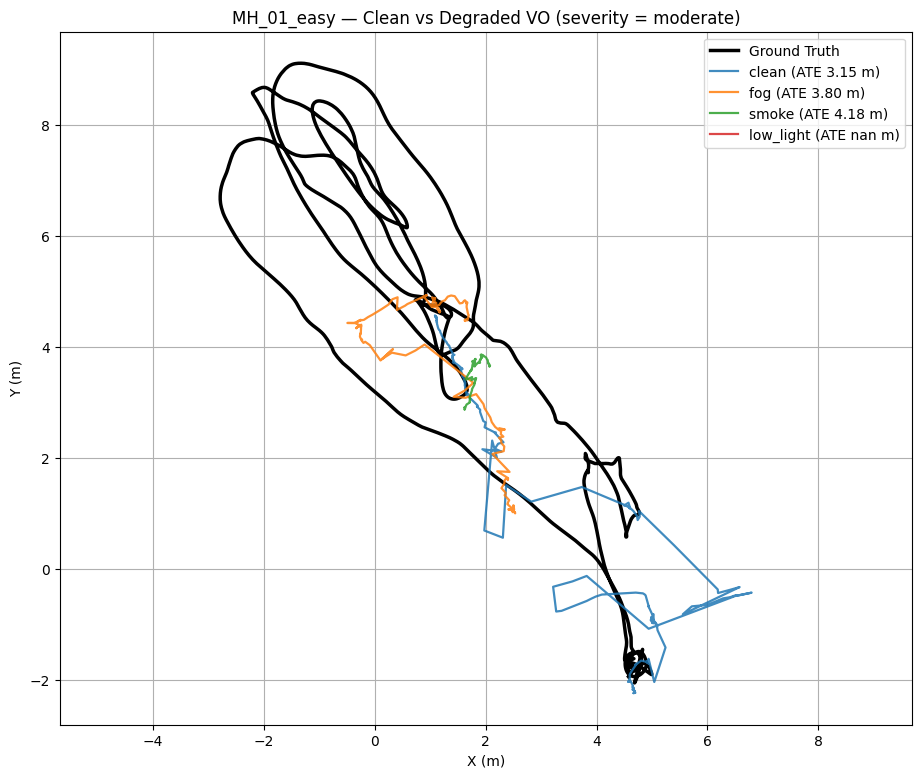

/tmp/ipykernel_6556/4287231436.py:546: UserWarning: Glyph 2447 (\N{BENGALI LETTER E}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(results_dir, "metrics_comparison.png"), dpi=200, bbox_inches="tight")
/tmp/ipykernel_6556/4287231436.py:546: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.savefig(os.path.join(results_dir, "metrics_comparison.png"), dpi=200, bbox_inches="tight")
/tmp/ipykernel_6556/4287231436.py:546: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(results_dir, "metrics_comparison.png"), dpi=200, bbox_inches="tight")
/tmp/ipykernel_6556/4287231436.py:546: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(results_dir, "metrics_comparison.png"), dpi=200, bbox_inches="tight")
/tmp/ipykernel_6556/4287231436.py:546: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.savefig(os.pa

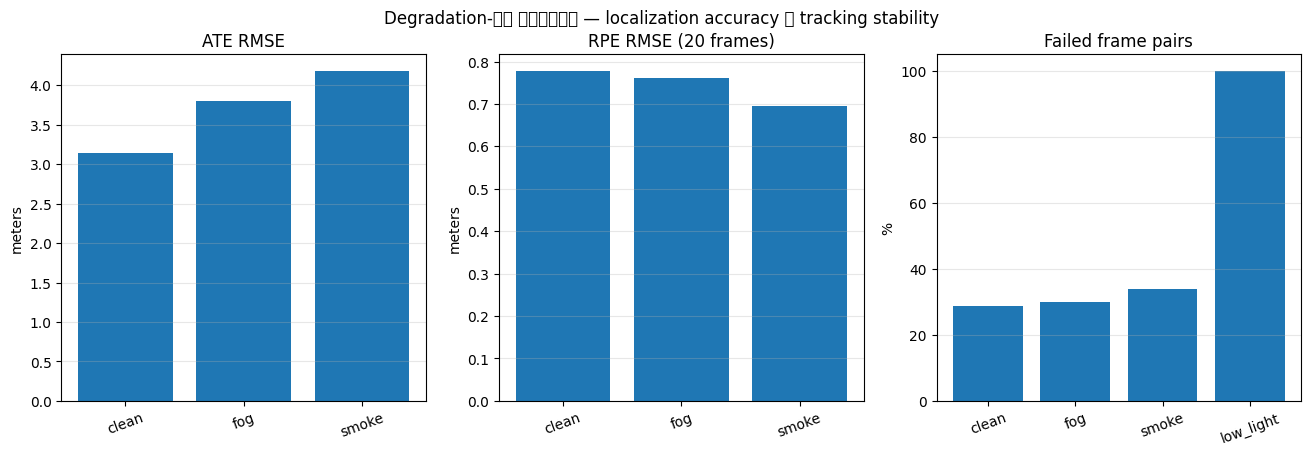

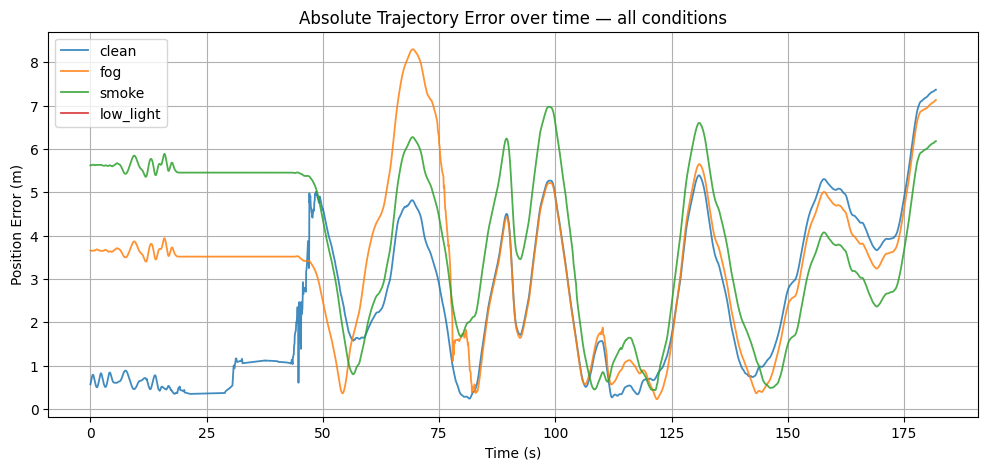


সব ফলাফল সেভ হয়েছে: /content/uav_project/results_week3

যাচাই করুন: degraded condition-গুলোতে ATE/RPE ও failed-frame % বেড়েছে কি না।
যদি প্রায় একই থাকে → SEVERITY = 'severe' করে আবার রান করুন।


In [1]:
# -*- coding: utf-8 -*-
"""
Week 3 — Degraded Visibility Simulation & Clean vs Degraded Comparison
=======================================================================
লক্ষ্য: synthetic fog / smoke / low-light প্রয়োগ করে দেখানো যে degradation
বাস্তবিকভাবেই localization accuracy খারাপ করে (ATE/RPE বাড়ে, tracking failure বাড়ে)।

Week 2-এর পাইপলাইনই এখানে reusable ফাংশনে রিফ্যাক্টর করা হয়েছে,
যাতে একই VO কোড ৪ বার (clean + ৩ degradation) চালানো যায়।

Colab-এ ধাপে ধাপে (উপর থেকে নিচে) রান করুন।
"""

# ============================================================
# ধাপ ১ — Drive মাউন্ট, ডেটাসেট প্রস্তুত (Week 2-এর মতোই)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile

zip_path = "/content/drive/MyDrive/MH_01_easy.zip"
work_dir = "/content/uav_project"
extract_dir = f"{work_dir}/data"

os.makedirs(work_dir, exist_ok=True)
assert os.path.exists(zip_path), f"ZIP ফাইল পাওয়া যায়নি: {zip_path}"

dataset_root = None
if os.path.exists(extract_dir):
    for root, dirs, files in os.walk(extract_dir):
        if "mav0" in dirs:
            dataset_root = os.path.join(root, "mav0")
            break

if dataset_root is None:
    os.makedirs(extract_dir, exist_ok=True)
    print("Extracting ZIP...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    for root, dirs, files in os.walk(extract_dir):
        if "mav0" in dirs:
            dataset_root = os.path.join(root, "mav0")
            break

assert dataset_root is not None, "mav0 ফোল্ডার খুঁজে পাওয়া যায়নি।"

cam0_dir = os.path.join(dataset_root, "cam0")
cam0_data = os.path.join(cam0_dir, "data")
cam0_csv = os.path.join(cam0_dir, "data.csv")
sensor_yaml = os.path.join(cam0_dir, "sensor.yaml")
gt_csv = os.path.join(dataset_root, "state_groundtruth_estimate0", "data.csv")

for p in [cam0_data, cam0_csv, sensor_yaml, gt_csv]:
    assert os.path.exists(p), f"পাওয়া যায়নি: {p}"

print("Dataset root :", dataset_root)
print("সব পাথ ঠিক আছে ✅")


# ============================================================
# ধাপ ২ — ইম্পোর্ট ও রেজাল্ট ফোল্ডার
# ============================================================

# !pip install -q opencv-python numpy pandas matplotlib scipy evo pyyaml

import cv2
import yaml
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as SciRot
from scipy.spatial.distance import pdist

results_dir = os.path.join(work_dir, "results_week3")
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

print("OpenCV:", cv2.__version__)


# ============================================================
# ধাপ ৩ — ক্যালিব্রেশন লোড
# ============================================================

with open(sensor_yaml, "r") as f:
    sensor_data = yaml.safe_load(f)

fx, fy, cx, cy = sensor_data["intrinsics"]
dist_coeffs = np.array(sensor_data["distortion_coefficients"], dtype=np.float64)
K = np.array([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]], dtype=np.float64)

print("Camera matrix K:\n", K)


# ============================================================
# ধাপ ৪ — CSV লোড ও কমন টাইম-উইন্ডো
# ============================================================

cam_df = pd.read_csv(cam0_csv)
gt_df = pd.read_csv(gt_csv)

cam_time_col, cam_file_col = "#timestamp [ns]", "filename"
gt_time_col = "#timestamp"
gt_x_col, gt_y_col, gt_z_col = " p_RS_R_x [m]", " p_RS_R_y [m]", " p_RS_R_z [m]"

cam_df[cam_time_col] = pd.to_numeric(cam_df[cam_time_col])
gt_df[gt_time_col] = pd.to_numeric(gt_df[gt_time_col])

start_time = max(cam_df[cam_time_col].min(), gt_df[gt_time_col].min())
end_time = min(cam_df[cam_time_col].max(), gt_df[gt_time_col].max())
cam_df = cam_df[(cam_df[cam_time_col] >= start_time) &
                (cam_df[cam_time_col] <= end_time)].reset_index(drop=True)

print("ব্যবহারযোগ্য ফ্রেম:", len(cam_df))


# ============================================================
# ধাপ ৫ — Degradation ফাংশন (Week 3-এর মূল নতুন অংশ)
# ============================================================
# cam0 গ্রেস্কেল, তাই সব degradation intensity-ভিত্তিক (রঙ-ভিত্তিক না)।
#
# SEVERITY_PRESETS-এ প্রতিটা mode-এর জন্য mild/moderate/severe আছে।
# শুরুতে 'moderate' দিয়ে চালান; পার্থক্য যথেষ্ট না হলে 'severe'-এ বাড়ান।

SEVERITY_PRESETS = {
    "fog": {
        # beta = scattering coefficient (যত বড়, তত ঘন কুয়াশা)
        # A = atmospheric light (উজ্জ্বল সাদাটে আভা)
        "mild":     {"beta": 0.6, "A": 200},
        "moderate": {"beta": 1.2, "A": 210},
        "severe":   {"beta": 2.0, "A": 220},
    },
    "smoke": {
        # fog-এর মতোই কিন্তু ধূসর (কম A) + blur, কারণ ধোঁয়া আলো ছড়ায় ও দৃশ্য ঘোলা করে
        "mild":     {"beta": 0.7, "A": 130, "blur": 3},
        "moderate": {"beta": 1.3, "A": 120, "blur": 5},
        "severe":   {"beta": 2.1, "A": 110, "blur": 7},
    },
    "low_light": {
        # gain = brightness গুণক, gamma > 1 = আরও অন্ধকার, noise_std = sensor noise
        "mild":     {"gain": 0.45, "gamma": 1.4, "noise_std": 4},
        "moderate": {"gain": 0.25, "gamma": 1.8, "noise_std": 7},
        "severe":   {"gain": 0.12, "gamma": 2.2, "noise_std": 10},
    },
}


def _depth_proxy(h, w):
    """
    সত্যিকারের depth map নেই, তাই একটা সহজ proxy ব্যবহার করা হচ্ছে:
    ছবির উপরের দিক = দূরে, নিচের দিক = কাছে (সামনে-তাকানো ক্যামেরার জন্য
    এটা একটা প্রচলিত approximation)। এতে fog উপরের দিকে বেশি ঘন দেখাবে —
    সমানভাবে সাদা করে দেওয়ার চেয়ে বাস্তবসম্মত।
    """
    d = np.linspace(1.0, 0.15, h).reshape(h, 1)
    return np.repeat(d, w, axis=1)


def degrade_image(img, mode=None, severity="moderate"):
    """
    গ্রেস্কেল ছবিতে synthetic degradation প্রয়োগ করে।
    mode: None (clean) / 'fog' / 'smoke' / 'low_light'
    """
    if mode is None or mode == "clean":
        return img

    assert mode in SEVERITY_PRESETS, f"অজানা mode: {mode}"
    p = SEVERITY_PRESETS[mode][severity]
    h, w = img.shape[:2]
    img_f = img.astype(np.float32)

    if mode in ("fog", "smoke"):
        # Atmospheric scattering model:  I = I0 * t + A * (1 - t),  t = exp(-beta * d)
        depth = _depth_proxy(h, w)
        transmission = np.exp(-p["beta"] * depth).astype(np.float32)
        out = img_f * transmission + p["A"] * (1.0 - transmission)
        if mode == "smoke":
            k = p["blur"]
            out = cv2.GaussianBlur(out, (k, k), 0)

    elif mode == "low_light":
        # প্রথমে gain দিয়ে brightness কমানো, তারপর gamma দিয়ে অন্ধকার আরও গাঢ় করা
        out = img_f * p["gain"]
        out = 255.0 * np.power(np.clip(out / 255.0, 0, 1), p["gamma"])
        # কম আলোয় সেন্সর noise বাড়ে — সেটাই যোগ করা হচ্ছে
        noise = np.random.normal(0, p["noise_std"], out.shape).astype(np.float32)
        out = out + noise

    return np.clip(out, 0, 255).astype(np.uint8)


def load_image(path, mode=None, severity="moderate"):
    """ছবি পড়ে → undistort → (প্রয়োজনে) degrade করে ফেরত দেয়।"""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.undistort(img, K, dist_coeffs)
    return degrade_image(img, mode=mode, severity=severity)


# ---- degradation চোখে দেখে যাচাই (একটা স্যাম্পল ফ্রেমে) ----
sample_path = os.path.join(cam0_data, str(cam_df.iloc[500][cam_file_col]))
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, mode in zip(axes, [None, "fog", "smoke", "low_light"]):
    ax.imshow(load_image(sample_path, mode=mode), cmap="gray", vmin=0, vmax=255)
    ax.set_title("clean" if mode is None else mode)
    ax.axis("off")
plt.suptitle("Degradation preview (severity = moderate)")
plt.savefig(os.path.join(results_dir, "degradation_preview.png"), dpi=200, bbox_inches="tight")
plt.show()


# ============================================================
# ধাপ ৬ — VO পাইপলাইন (reusable ফাংশন হিসেবে)
# ============================================================
# Week 2-এর relative-scale-propagation VO-ই এখানে ফাংশনে মোড়া হয়েছে,
# যাতে একই কোড ৪টা ভিন্ন condition-এ চালানো যায়।

orb = cv2.ORB_create(nfeatures=2500, scaleFactor=1.2, nlevels=8,
                     edgeThreshold=31, patchSize=31, fastThreshold=20)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

MIN_COMMON_PTS_FOR_SCALE = 6
RATIO_CLIP = (0.2, 5.0)


def build_projection_matrix(K_mat, R_mat, t_vec):
    return K_mat @ np.hstack([R_mat, t_vec.reshape(3, 1)])


def triangulate_points(P1, P2, pts1, pts2):
    pts4d = cv2.triangulatePoints(P1, P2, pts1.T.astype(np.float64), pts2.T.astype(np.float64))
    return (pts4d[:3] / pts4d[3]).T


def run_vo_pipeline(mode=None, severity="moderate", label="clean", verbose=True):
    """
    একটা নির্দিষ্ট visibility condition-এ পুরো VO চালায়।
    রিটার্ন: dict (positions, rotations, timestamps, success, failed, ...)
    """
    R_wc = np.eye(3, dtype=np.float64)
    t_wc = np.zeros((3, 1), dtype=np.float64)

    positions, rotations, timestamps = [], [], []
    positions.append(t_wc.reshape(3))
    rotations.append(R_wc.copy())
    timestamps.append(int(cam_df.iloc[0][cam_time_col]))

    first_path = os.path.join(cam0_data, str(cam_df.iloc[0][cam_file_col]))
    prev_img = load_image(first_path, mode=mode, severity=severity)
    assert prev_img is not None, "প্রথম ছবি পড়া যায়নি।"

    prev_kp, prev_des = orb.detectAndCompute(prev_img, None)
    if prev_des is None or len(prev_kp) < 20:
        raise RuntimeError(f"[{label}] প্রথম ফ্রেমে যথেষ্ট ফিচার নেই — severity খুব বেশি হতে পারে।")

    successful_pairs, failed_pairs, scale_estimated_count = 0, 0, 0
    inlier_counts, feature_counts = [], [len(prev_kp)]

    prev_frame_link, prev_R_rel, prev_t_rel = None, None, None
    step_scale = 1.0

    if verbose:
        print(f"\n[{label}] VO শুরু হচ্ছে... (mode={mode}, severity={severity})")

    for i in range(1, len(cam_df)):
        img_path = os.path.join(cam0_data, str(cam_df.iloc[i][cam_file_col]))
        curr_img = load_image(img_path, mode=mode, severity=severity)
        if curr_img is None:
            failed_pairs += 1
            continue

        curr_kp, curr_des = orb.detectAndCompute(curr_img, None)
        feature_counts.append(0 if curr_kp is None else len(curr_kp))
        if curr_des is None or len(curr_kp) < 20:
            failed_pairs += 1
            prev_frame_link = None
            continue

        try:
            knn_matches = bf.knnMatch(prev_des, curr_des, k=2)
        except cv2.error:
            failed_pairs += 1
            prev_frame_link = None
            continue

        good_matches = [m for pair in knn_matches if len(pair) == 2
                        for m, n in [pair] if m.distance < 0.75 * n.distance]

        if len(good_matches) < 8:
            failed_pairs += 1
            prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
            prev_frame_link = None
            continue

        pts_prev = np.float32([prev_kp[m.queryIdx].pt for m in good_matches])
        pts_curr = np.float32([curr_kp[m.trainIdx].pt for m in good_matches])
        prev_idx = np.array([m.queryIdx for m in good_matches])
        curr_idx = np.array([m.trainIdx for m in good_matches])

        E, mask_E = cv2.findEssentialMat(pts_prev, pts_curr, K,
                                         method=cv2.RANSAC, prob=0.999, threshold=1.0)
        if E is None or mask_E is None:
            failed_pairs += 1
            prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
            prev_frame_link = None
            continue

        inlier_mask = mask_E.ravel().astype(bool)
        pts_prev_in, pts_curr_in = pts_prev[inlier_mask], pts_curr[inlier_mask]
        prev_idx_in, curr_idx_in = prev_idx[inlier_mask], curr_idx[inlier_mask]
        inlier_counts.append(len(pts_prev_in))

        if len(pts_prev_in) < 8:
            failed_pairs += 1
            prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
            prev_frame_link = None
            continue

        try:
            retval, R_rel, t_rel, _ = cv2.recoverPose(E, pts_prev_in, pts_curr_in, K)
        except cv2.error:
            failed_pairs += 1
            prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
            prev_frame_link = None
            continue

        if retval < 8:
            failed_pairs += 1
            prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
            prev_frame_link = None
            continue

        t_rel_unit = t_rel.reshape(3)

        # --- relative scale propagation (Week 2-এর মতোই) ---
        if prev_frame_link is not None and prev_R_rel is not None:
            common_idx = np.intersect1d(prev_idx_in, np.array(list(prev_frame_link.keys())))
            if len(common_idx) >= MIN_COMMON_PTS_FOR_SCALE:
                pts_tm2 = np.array([prev_frame_link[idx] for idx in common_idx], dtype=np.float64)
                pts_tm1 = np.array([prev_kp[idx].pt for idx in common_idx], dtype=np.float64)
                this_map = dict(zip(prev_idx_in.tolist(), pts_curr_in.tolist()))
                pts_t = np.array([this_map[idx] for idx in common_idx], dtype=np.float64)

                P_ref = build_projection_matrix(K, np.eye(3), np.zeros(3))
                P_tm2 = build_projection_matrix(K, prev_R_rel.T, -prev_R_rel.T @ prev_t_rel)
                P_t = build_projection_matrix(K, R_rel, t_rel_unit)

                X_A = triangulate_points(P_tm2, P_ref, pts_tm2, pts_tm1)
                X_B = triangulate_points(P_ref, P_t, pts_tm1, pts_t)

                dist_A, dist_B = pdist(X_A), pdist(X_B)
                valid = ((dist_A > 1e-6) & (dist_B > 1e-6) &
                         np.isfinite(dist_A) & np.isfinite(dist_B))
                if np.any(valid):
                    ratio = float(np.median(dist_A[valid] / dist_B[valid]))
                    step_scale *= float(np.clip(ratio, RATIO_CLIP[0], RATIO_CLIP[1]))
                    scale_estimated_count += 1

        t_rel_scaled = (t_rel_unit * step_scale).reshape(3, 1)
        R_wc = R_wc @ R_rel.T
        t_wc = t_wc - R_wc @ t_rel_scaled

        positions.append(t_wc.reshape(3))
        rotations.append(R_wc.copy())
        timestamps.append(int(cam_df.iloc[i][cam_time_col]))
        successful_pairs += 1

        prev_frame_link = dict(zip(curr_idx_in.tolist(), pts_prev_in.tolist()))
        prev_R_rel, prev_t_rel = R_rel, t_rel_unit
        prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des

        if verbose and i % 500 == 0:
            print(f"  [{label}] Frame {i:5d}/{len(cam_df)} | "
                  f"Success: {successful_pairs:5d} | Failed: {failed_pairs:5d}")

    total = successful_pairs + failed_pairs
    return {
        "label": label,
        "mode": mode,
        "severity": severity if mode else "-",
        "positions": np.asarray(positions, dtype=np.float64),
        "rotations": np.asarray(rotations, dtype=np.float64),
        "timestamps": np.asarray(timestamps, dtype=np.int64),
        "successful_pairs": successful_pairs,
        "failed_pairs": failed_pairs,
        "failed_pct": 100.0 * failed_pairs / total if total else float("nan"),
        "mean_features": float(np.mean(feature_counts)) if feature_counts else 0.0,
        "mean_inliers": float(np.mean(inlier_counts)) if inlier_counts else 0.0,
        "scale_estimated_count": scale_estimated_count,
    }


# ============================================================
# ধাপ ৭ — মূল্যায়ন ফাংশন (alignment + ATE + RPE)
# ============================================================

gt_time = gt_df[gt_time_col].to_numpy(dtype=np.float64)
gt_position = np.column_stack([
    gt_df[gt_x_col].to_numpy(dtype=np.float64),
    gt_df[gt_y_col].to_numpy(dtype=np.float64),
    gt_df[gt_z_col].to_numpy(dtype=np.float64)
])
gt_time, _uidx = np.unique(gt_time, return_index=True)
gt_position = gt_position[_uidx]


def interpolate_gt(timestamps_ns):
    out = np.zeros((len(timestamps_ns), 3))
    for axis in range(3):
        out[:, axis] = np.interp(timestamps_ns.astype(np.float64), gt_time, gt_position[:, axis])
    return out


def umeyama_alignment(source, target, with_scale=True):
    source, target = np.asarray(source), np.asarray(target)
    n = source.shape[0]
    mu_src, mu_tgt = source.mean(axis=0), target.mean(axis=0)
    src_c, tgt_c = source - mu_src, target - mu_tgt
    cov = (tgt_c.T @ src_c) / n
    U, D, Vt = np.linalg.svd(cov)
    S = np.eye(3)
    if np.linalg.det(U @ Vt) < 0:
        S[-1, -1] = -1
    R = U @ S @ Vt
    scale = (np.sum(D * np.diag(S)) / (np.sum(src_c ** 2) / n)) if with_scale else 1.0
    t = mu_tgt - scale * (R @ mu_src)
    return scale * (R @ source.T).T + t, scale


def evaluate_run(run, delta_frames=20):
    """একটা VO রানের ATE/RPE হিসাব করে, run dict-এ ফলাফল যোগ করে ফেরত দেয়।"""
    gt_interp = interpolate_gt(run["timestamps"])
    aligned, scale = umeyama_alignment(run["positions"], gt_interp, with_scale=True)

    ate_errors = np.linalg.norm(aligned - gt_interp, axis=1)
    ate_rmse = float(np.sqrt(np.mean(ate_errors ** 2)))

    rpe_errors = []
    for i in range(len(aligned) - delta_frames):
        j = i + delta_frames
        rpe_errors.append(np.linalg.norm((aligned[j] - aligned[i]) - (gt_interp[j] - gt_interp[i])))
    rpe_errors = np.asarray(rpe_errors)
    rpe_rmse = float(np.sqrt(np.mean(rpe_errors ** 2))) if len(rpe_errors) else float("nan")

    run.update({
        "gt_interp": gt_interp,
        "aligned": aligned,
        "alignment_scale": scale,
        "ate_errors": ate_errors,
        "ate_rmse": ate_rmse,
        "ate_mean": float(np.mean(ate_errors)),
        "ate_max": float(np.max(ate_errors)),
        "rpe_rmse": rpe_rmse,
    })
    return run


# ============================================================
# ধাপ ৮ — ৪টা condition-এ VO চালানো
# ============================================================
# ⚠️ এই সেলটা সবচেয়ে বেশি সময় নেবে (৪ বার পুরো সিকোয়েন্স, প্রায় ৪x Week 2)।
# চাইলে প্রথমে cam_df = cam_df.iloc[:800] দিয়ে ছোট subset-এ টেস্ট করে নিন।

SEVERITY = "moderate"   # পার্থক্য যথেষ্ট না হলে "severe" করুন

conditions = [
    (None,        "clean"),
    ("fog",       "fog"),
    ("smoke",     "smoke"),
    ("low_light", "low_light"),
]

runs = []
for mode, label in conditions:
    run = run_vo_pipeline(mode=mode, severity=SEVERITY, label=label)
    run = evaluate_run(run)
    runs.append(run)
    print(f"[{label}] সম্পন্ন — ATE RMSE: {run['ate_rmse']:.4f} m | "
          f"RPE RMSE: {run['rpe_rmse']:.4f} m | Failed: {run['failed_pct']:.1f}%")


# ============================================================
# ধাপ ৯ — তুলনা টেবিল (Presentation 3-এর মূল ডেলিভারেবল)
# ============================================================

table = pd.DataFrame([{
    "Condition": r["label"],
    "Severity": r["severity"],
    "ATE RMSE (m)": round(r["ate_rmse"], 4),
    "ATE Mean (m)": round(r["ate_mean"], 4),
    "ATE Max (m)": round(r["ate_max"], 4),
    "RPE RMSE (m)": round(r["rpe_rmse"], 4),
    "Failed frames (%)": round(r["failed_pct"], 2),
    "Mean features": round(r["mean_features"], 1),
    "Mean inliers": round(r["mean_inliers"], 1),
} for r in runs])

# clean-এর তুলনায় ATE কত গুণ বাড়ল — degradation-এর প্রভাব সরাসরি দেখায়
clean_ate = table.loc[table["Condition"] == "clean", "ATE RMSE (m)"].values[0]
table["ATE vs clean (x)"] = (table["ATE RMSE (m)"] / clean_ate).round(2)

print("\n" + "=" * 90)
print("WEEK 3 — CLEAN vs DEGRADED তুলনা")
print("=" * 90)
print(table.to_string(index=False))

table.to_csv(os.path.join(results_dir, "week3_comparison.csv"), index=False)


# ============================================================
# ধাপ ১০ — প্লট: trajectory, bar chart, error-over-time
# ============================================================

# (ক) সব trajectory একসাথে ground truth-এর পাশে
plt.figure(figsize=(11, 9))
plt.plot(runs[0]["gt_interp"][:, 0], runs[0]["gt_interp"][:, 1],
         label="Ground Truth", linewidth=2.5, color="black")
for r in runs:
    plt.plot(r["aligned"][:, 0], r["aligned"][:, 1],
             label=f"{r['label']} (ATE {r['ate_rmse']:.2f} m)", linewidth=1.6, alpha=0.85)
plt.xlabel("X (m)"); plt.ylabel("Y (m)")
plt.title(f"MH_01_easy — Clean vs Degraded VO (severity = {SEVERITY})")
plt.legend(); plt.axis("equal"); plt.grid(True)
plt.savefig(os.path.join(results_dir, "trajectory_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()

# (খ) ATE / RPE / failure bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
labels = [r["label"] for r in runs]
for ax, key, title, ylab in [
    (axes[0], "ate_rmse", "ATE RMSE", "meters"),
    (axes[1], "rpe_rmse", "RPE RMSE (20 frames)", "meters"),
    (axes[2], "failed_pct", "Failed frame pairs", "%"),
]:
    ax.bar(labels, [r[key] for r in runs])
    ax.set_title(title); ax.set_ylabel(ylab)
    ax.grid(True, axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Degradation-এর প্রভাব — localization accuracy ও tracking stability")
plt.savefig(os.path.join(results_dir, "metrics_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()

# (গ) error-over-time, সব condition একসাথে
plt.figure(figsize=(12, 5))
for r in runs:
    t_sec = (r["timestamps"] - r["timestamps"][0]) / 1e9
    plt.plot(t_sec, r["ate_errors"], linewidth=1.3, alpha=0.85, label=r["label"])
plt.xlabel("Time (s)"); plt.ylabel("Position Error (m)")
plt.title("Absolute Trajectory Error over time — all conditions")
plt.legend(); plt.grid(True)
plt.savefig(os.path.join(results_dir, "ate_over_time_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()


# ============================================================
# ধাপ ১১ — ফলাফল সেভ
# ============================================================

for r in runs:
    np.savetxt(os.path.join(results_dir, f"trajectory_{r['label']}.txt"),
               np.column_stack([r["timestamps"], r["aligned"]]),
               header="timestamp_ns x y z")

print("\nসব ফলাফল সেভ হয়েছে:", results_dir)
print("\nযাচাই করুন: degraded condition-গুলোতে ATE/RPE ও failed-frame % বেড়েছে কি না।")
print("যদি প্রায় একই থাকে → SEVERITY = 'severe' করে আবার রান করুন।")